# 📘 Project 17 — Privacy-Preserving Multimodal Medical RAG
**Team No.:** 8  **Team Members:** Auro Aditya Biswal; Ashutosh Parida; Abinash Das; Anupam Panda

**Proposed Hybrid Model:** BioClinicalBERT + Medical ViT + Cross-Modal RAG

**Dataset / Source:** Indiana University Chest X-rays (paired image + radiology report corpus)
**Dataset Link:** https://www.kaggle.com/datasets/raddar/chest-xrays-indiana-university

**Task Type:** Cross-modal retrieval — image-to-report / report-to-image matching (RAG-style)

---
## Data-Model Compatibility Note
This dataset is a genuinely strong fit: real paired chest X-ray images + free-text radiology
reports (findings/impression), exactly the paired text/image corpus the tracker/README ask for.
- **Medical ViT**: a Vision Transformer over X-ray images - directly buildable.
- **BioClinicalBERT**: the full pretrained BioClinicalBERT checkpoint is a large download; this
  notebook uses a lightweight from-scratch clinical-text Transformer encoder over report tokens
  (same architectural family - token embedding + multi-head self-attention encoder) to stay within
  typical free-tier Colab download/runtime budgets, and documents this substitution rather than
  silently claiming the full pretrained checkpoint was used. Swap in
  `AutoModel.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")` if you have the runtime budget.
- **Cross-Modal RAG**: implemented as real cosine-similarity retrieval in a shared image/text
  embedding space (contrastive-style: retrieve the report whose embedding is closest to a given
  image's embedding, and vice versa) - a genuine retrieval mechanism, not a decorative label.
- **Privacy-preserving**: this public dataset is already de-identified; "privacy-preserving" is
  operationalized here as (a) never using patient-identifying metadata as a feature and (b) adding
  Gaussian noise calibrated to a simple differential-privacy budget on the shared embedding space
  before retrieval - a real, if basic, privacy mechanism, not just a name.

**Verdict: PARTIAL** - image+text branches and cross-modal retrieval are faithful; the text
encoder is a lightweight substitute for the full pretrained BioClinicalBERT for Colab feasibility
(documented, easy to swap back in).

**Task framing note**: retrieval/RAG doesn't have a single scalar "accuracy" the way classification
does - this notebook evaluates with retrieval metrics (Recall@K, MRR) per the tracker's own listed
metric family for RAG tasks, not classification accuracy.

**How to run:** `Runtime -> Change runtime type -> GPU`, then `Runtime -> Run all`. Upload your
Kaggle API token when prompted in Section 1.


## 0. Setup — Environment, Imports, Reproducibility

In [1]:
# Colab already ships numpy/pandas/scikit-learn/matplotlib/seaborn/torch - do NOT reinstall those (version conflicts).
# Only install what's actually missing.
!pip -q install kaggle tqdm pillow tabulate


In [2]:
import os
import sys
import json
import random
import platform
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

from sklearn.model_selection import train_test_split

SEED = 42
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
set_seed()

assert torch.cuda.is_available(), "GPU required: in Colab select Runtime > Change runtime type > GPU."

DEVICE = torch.device("cuda:0")
print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device selected:", DEVICE)
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))


Python: 3.13.15
PyTorch: 2.11.0+cu128
CUDA available: True
Device selected: cuda:0
GPU name: Tesla T4


### CONFIG

In [3]:
CONFIG = {
    "project_no": "17",
    "project_name": "Privacy-Preserving_Multimodal_Medical_RAG",
    "team_no": "8",
    "task_type": "cross_modal_retrieval",
    "modality": "image_text",
    "kaggle_dataset_slug": "raddar/chest-xrays-indiana-university",
    "dataset_source": "Indiana University Chest X-rays (paired image+report)",
    "max_pairs": 3000,   # cap for Colab feasibility
    "image_size": 128,
    "max_text_len": 100,
    "max_vocab": 4000,
    "embed_dim": 128,
    "dp_noise_std": 0.05,  # simple Gaussian DP-style noise on shared embeddings
    "split_ratios": {"train": 0.70, "val": 0.15, "test": 0.15},
    "random_seed": SEED,
    "batch_size": 32,
    "epochs": 15,
    "learning_rate": 1e-3,
    "early_stop_patience": 5,
    "data_raw_dir": "data/17/raw",
    "data_processed_dir": "data/17/processed",
    "figures_dir": "data/17/figures",
    "results_dir": "data/17/results",
    "reports_dir": "data/17/reports",
}
for d in [CONFIG["data_raw_dir"], CONFIG["data_processed_dir"], CONFIG["figures_dir"],
          CONFIG["results_dir"], CONFIG["reports_dir"]]:
    os.makedirs(d, exist_ok=True)
CONFIG


{'project_no': '17',
 'project_name': 'Privacy-Preserving_Multimodal_Medical_RAG',
 'team_no': '8',
 'task_type': 'cross_modal_retrieval',
 'modality': 'image_text',
 'kaggle_dataset_slug': 'raddar/chest-xrays-indiana-university',
 'dataset_source': 'Indiana University Chest X-rays (paired image+report)',
 'max_pairs': 3000,
 'image_size': 128,
 'max_text_len': 100,
 'max_vocab': 4000,
 'embed_dim': 128,
 'dp_noise_std': 0.05,
 'split_ratios': {'train': 0.7, 'val': 0.15, 'test': 0.15},
 'random_seed': 42,
 'batch_size': 32,
 'epochs': 15,
 'learning_rate': 0.001,
 'early_stop_patience': 5,
 'data_raw_dir': 'data/17/raw',
 'data_processed_dir': 'data/17/processed',
 'figures_dir': 'data/17/figures',
 'results_dir': 'data/17/results',
 'reports_dir': 'data/17/reports'}

## 1. Dataset Download

In [4]:
from google.colab import files
if not os.path.exists("/root/.kaggle/kaggle.json"):
    print("Upload your kaggle.json:")
    uploaded = files.upload()
    os.makedirs("/root/.kaggle", exist_ok=True)
    for fname in uploaded:
        if fname.endswith(".json"):
            os.replace(fname, "/root/.kaggle/kaggle.json")
    os.chmod("/root/.kaggle/kaggle.json", 0o600)

!kaggle datasets download -d {CONFIG["kaggle_dataset_slug"]} -p {CONFIG["data_raw_dir"]} --unzip


Dataset URL: https://www.kaggle.com/datasets/raddar/chest-xrays-indiana-university
License(s): Attribution-NonCommercial-NoDerivatives 4.0 International (CC BY-NC-ND 4.0)


  0% 30.0M/13.2G [00:00<01:40, 140MB/s] 

  1% 78.0M/13.2G [00:00<01:40, 140MB/s]

  1% 119M/13.2G [00:01<01:50, 127MB/s]  

  1% 148M/13.2G [00:01<02:20, 99.5MB/s]

...

 99% 13.1G/13.2G [02:26<00:00, 123MB/s]

 99% 13.1G/13.2G [02:26<00:00, 95.9MB/s]

100% 13.1G/13.2G [02:26<00:00, 110MB/s] 

100% 13.2G/13.2G [02:27<00:00, 140MB/s]

100% 13.2G/13.2G [02:27<00:00, 95.9MB/s]



In [5]:
raw_files = []
for root, _, fnames in os.walk(CONFIG["data_raw_dir"]):
    for fn in fnames:
        raw_files.append(os.path.join(root, fn))
print(f"{len(raw_files)} files found")
assert len(raw_files) > 0, "No files found - check Section 1 download step before continuing."
img_files = [f for f in raw_files if f.lower().endswith((".png", ".jpg", ".jpeg"))]
csv_files = [f for f in raw_files if f.lower().endswith(".csv")]
print("Images:", len(img_files), "| CSVs:", len(csv_files))
for f in csv_files[:10]:
    print(f, "-", os.path.getsize(f), "bytes")


7472 files found
Images: 7470 | CSVs: 2
data/17/raw/indiana_reports.csv - 1679512 bytes
data/17/raw/indiana_projections.csv - 289397 bytes


## 2. Load Raw Data

In [6]:
assert len(csv_files) >= 1, f"No report/metadata CSV found among: {raw_files[:10]}"
RAW_FILE = max(csv_files, key=os.path.getsize)
print("Using report CSV:", RAW_FILE)

reports_df = pd.read_csv(RAW_FILE)
print(reports_df.shape)
print(list(reports_df.columns))
reports_df.head()


Using report CSV: data/17/raw/indiana_reports.csv
(3851, 8)
['uid', 'MeSH', 'Problems', 'image', 'indication', 'comparison', 'findings', 'impression']


,uid,MeSH,Problems,image,indication,comparison,findings,impression
0,1,normal,normal,Xray Chest PA and Lateral,Positive TB test,None.,The cardiac silhouette and mediastinum size ar...,Normal chest x-XXXX.
1,2,Cardiomegaly/borderline;Pulmonary Artery/enlarged,Cardiomegaly;Pulmonary Artery,"Chest, 2 views, frontal and lateral",Preop bariatric surgery.,None.,Borderline cardiomegaly. Midline sternotomy XX...,No acute pulmonary findings.
2,3,normal,normal,Xray Chest PA and Lateral,"rib pain after a XXXX, XXXX XXXX steps this XX...",NaN,NaN,"No displaced rib fractures, pneumothorax, or p..."
3,4,"Pulmonary Disease, Chronic Obstructive;Bullous...","Pulmonary Disease, Chronic Obstructive;Bullous...","PA and lateral views of the chest XXXX, XXXX a...",XXXX-year-old XXXX with XXXX.,None available,There are diffuse bilateral interstitial and a...,1. Bullous emphysema and interstitial fibrosis...
4,5,Osteophyte/thoracic vertebrae/multiple/small;T...,Osteophyte;Thickening;Lung,Xray Chest PA and Lateral,Chest and nasal congestion.,NaN,The cardiomediastinal silhouette and pulmonary...,No acute cardiopulmonary abnormality.


## 3. Exploratory Data Analysis (EDA)

In [7]:
text_candidates = [c for c in reports_df.columns if any(k in c.lower() for k in ["finding", "impression", "report", "caption", "text"])]
image_id_candidates = [c for c in reports_df.columns if any(k in c.lower() for k in ["uid", "image", "filename", "id"])]
assert len(text_candidates) >= 1, f"Could not find a report-text column among: {list(reports_df.columns)}"
TEXT_COL = text_candidates[0]
IMG_ID_COL = image_id_candidates[0] if image_id_candidates else None
print("Text column:", TEXT_COL, "| Image-ID column:", IMG_ID_COL)

reports_df = reports_df.dropna(subset=[TEXT_COL])
reports_df["_text_len"] = reports_df[TEXT_COL].astype(str).str.split().apply(len)
print("Report count:", len(reports_df))
print(reports_df["_text_len"].describe())


Text column: findings | Image-ID column: uid
Report count: 3337
count    3337.000000
mean       31.453401
std        14.505694
min         7.000000
25%        21.000000
50%        29.000000
75%        38.000000
max       169.000000
Name: _text_len, dtype: float64


In [ ]:
# Build image-filename lookup by basename (id columns often reference filename stems)
img_by_stem = {}
img_by_name = {}
for p in img_files:
    stem = os.path.splitext(os.path.basename(p))[0]
    img_by_stem[stem] = p
    img_by_name[os.path.basename(p)] = p

# Diagnostic: inspect the actual ID/filename formats being joined before picking a strategy.
print("Sample report IDs (uid):", reports_df[IMG_ID_COL].astype(str).head(5).tolist())
print("Sample image filenames:", [os.path.basename(p) for p in img_files[:5]])

# This dataset ships a dedicated uid -> filename mapping (indiana_projections.csv, one row per
# image; each report/uid has ~2 projections/images on average - 7470 images for 3337 reports).
# Prefer that explicit mapping over filename-guessing: a short numeric uid like "1" is either a
# substring of many filenames (ambiguous, rejected by the unambiguous-match rule below) or fails
# to match at all, which is why the old substring-only approach paired only 141/3337 reports.
proj_files = [f for f in csv_files if "project" in os.path.basename(f).lower()]
uid_to_image = {}
if proj_files:
    proj_df = pd.read_csv(proj_files[0])
    print("Projections file:", proj_files[0], "columns:", list(proj_df.columns))
    filename_col = next((c for c in proj_df.columns if "file" in c.lower()), None)
    uid_col = next((c for c in proj_df.columns if c.lower() == "uid"), None)
    if filename_col and uid_col:
        proj_df["_resolved_path"] = proj_df[filename_col].map(img_by_name)
        matched = proj_df.dropna(subset=["_resolved_path"])
        print(f"Projections rows matched to an on-disk image: {len(matched)}/{len(proj_df)}")
        # multiple images (projections) can share a uid - keep the first for a clean 1:1 pair
        uid_to_image = matched.drop_duplicates(subset=[uid_col]).set_index(uid_col)["_resolved_path"].to_dict()
        uid_to_image = {str(k): v for k, v in uid_to_image.items()}
print("uid -> image mappings resolved from projections file:", len(uid_to_image))

def resolve_image_path(row):
    if IMG_ID_COL is None:
        return None
    key = str(row[IMG_ID_COL])
    if key in uid_to_image:
        return uid_to_image[key]
    if key in img_by_stem:
        return img_by_stem[key]
    # fuzzy fallback: only accept a substring match if it's unambiguous (exactly
    # one candidate), otherwise skip pairing rather than risk pairing the wrong image
    matches = [p for stem, p in img_by_stem.items() if key in stem or stem in key]
    return matches[0] if len(matches) == 1 else None

reports_df["_image_path"] = reports_df.apply(resolve_image_path, axis=1)
paired_df = reports_df.dropna(subset=["_image_path"]).reset_index(drop=True)
print("Paired image-report rows:", len(paired_df), "/ total reports:", len(reports_df))
assert len(paired_df) > 0, "No image-report pairs could be resolved - inspect ID/filename conventions above."
paired_df = paired_df.head(CONFIG["max_pairs"])

# --- Pairing sanity check (catch a degenerate join early, e.g. an overly strict/loose
# match that collapses pairs onto one image or produces a near-empty paired set) ---
print("Paired image-report diversity check: unique image paths =", paired_df["_image_path"].nunique(), "/ pairs =", len(paired_df))
assert paired_df["_image_path"].nunique() > 1, f"DEGENERATE TARGET: only {paired_df['_image_path'].nunique()} unique paired image(s) found - check upstream join/filter logic before proceeding."
if len(paired_df) < 100:
    print(f"WARNING: very small paired dataset ({len(paired_df)} rows) - check upstream row-limiting/join logic before proceeding.")

**Data quality memo**

In [9]:
missing = reports_df.isnull().mean().sort_values(ascending=False)
data_quality_memo = f"""# Data Quality Memo - Project 17: Privacy-Preserving Multimodal Medical RAG

## Dataset
- Source: Indiana University Chest X-rays ({RAW_FILE} + {len(img_files)} images)
- Paired image-report rows used: {len(paired_df)} (capped at CONFIG['max_pairs']={CONFIG['max_pairs']})
- Text column: {TEXT_COL} | Image-ID column: {IMG_ID_COL}

## Missingness
{missing[missing > 0].to_string() if (missing > 0).any() else "No missing values."}

## Leakage risks identified
- No repeated-patient grouping confirmed at inspection time; multiple images can correspond to the
  same study - a stratified/random split (Section 5) is used as a documented simplification. A
  full run should group by patient/study ID if that column is present in a given release.

## Adaptation note
BioClinicalBERT approximated with a lightweight from-scratch text Transformer (Colab feasibility);
Privacy-preserving = de-identified public data + Gaussian noise on shared embeddings before
retrieval (basic DP-style mechanism, documented in notebook header, not full formal DP).
"""
with open(os.path.join(CONFIG["reports_dir"], "data_quality_memo.md"), "w") as f:
    f.write(data_quality_memo)
print(data_quality_memo)


# Data Quality Memo - Project 17: Privacy-Preserving Multimodal Medical RAG

## Dataset
- Source: Indiana University Chest X-rays (data/17/raw/indiana_reports.csv + 7470 images)
- Paired image-report rows used: 141 (capped at CONFIG['max_pairs']=3000)
- Text column: findings | Image-ID column: uid

## Missingness
_image_path    0.957746
comparison     0.251423
indication     0.015883
impression     0.001798

## Leakage risks identified
- No repeated-patient grouping confirmed at inspection time; multiple images can correspond to the
  same study - a stratified/random split (Section 5) is used as a documented simplification. A
  full run should group by patient/study ID if that column is present in a given release.

## Adaptation note
BioClinicalBERT approximated with a lightweight from-scratch text Transformer (Colab feasibility);
Privacy-preserving = de-identified public data + Gaussian noise on shared embeddings before
retrieval (basic DP-style mechanism, documented in notebook heade

## 4. Preprocessing & Feature Engineering

In [10]:
def clean_text(s):
    return re.sub(r"[^a-z0-9\s]", " ", str(s).lower())

paired_df["_clean_text"] = paired_df[TEXT_COL].apply(clean_text)
IMG_SIZE = CONFIG["image_size"]
img_transform = T.Compose([T.Resize((IMG_SIZE, IMG_SIZE)), T.Grayscale(num_output_channels=1), T.ToTensor()])

def load_image(path):
    try:
        img = Image.open(path).convert("RGB")
        return img_transform(img)
    except Exception:
        return torch.zeros(1, IMG_SIZE, IMG_SIZE)


## 5. Train / Validation / Test Split

In [11]:
ratios = CONFIG["split_ratios"]
train_df, rest_df = train_test_split(paired_df, train_size=ratios["train"], random_state=SEED)
rel_val = ratios["val"] / (ratios["val"] + ratios["test"])
val_df, test_df = train_test_split(rest_df, train_size=rel_val, random_state=SEED)
print("Train / Val / Test sizes:", len(train_df), len(val_df), len(test_df))

manifest = {"train_pairs": len(train_df), "val_pairs": len(val_df), "test_pairs": len(test_df)}
with open(os.path.join(CONFIG["data_processed_dir"], "split_manifest.json"), "w") as f:
    json.dump(manifest, f, indent=2, default=str)
train_df[[TEXT_COL, "_image_path"]].to_csv(os.path.join(CONFIG["data_processed_dir"], "train.csv"), index=False)
val_df[[TEXT_COL, "_image_path"]].to_csv(os.path.join(CONFIG["data_processed_dir"], "val.csv"), index=False)
test_df[[TEXT_COL, "_image_path"]].to_csv(os.path.join(CONFIG["data_processed_dir"], "test.csv"), index=False)
manifest


Train / Val / Test sizes: 98 21 22


{'train_pairs': 98, 'val_pairs': 21, 'test_pairs': 22}

In [12]:
from collections import Counter
word_counts = Counter()
for t in train_df["_clean_text"]:
    word_counts.update(t.split())
vocab = ["<pad>", "<unk>"] + [w for w, _ in word_counts.most_common(CONFIG["max_vocab"] - 2)]
word_to_idx = {w: i for i, w in enumerate(vocab)}
VOCAB_SIZE = len(vocab)

def encode_text(t, max_len):
    ids = [word_to_idx.get(w, 1) for w in t.split()[:max_len]]
    return ids + [0] * (max_len - len(ids))

print("Vocab size:", VOCAB_SIZE)


Vocab size: 411


## 6. PyTorch Dataset & DataLoader

In [13]:
class ImageReportDataset(Dataset):
    def __init__(self, split_df):
        self.paths = split_df["_image_path"].tolist()
        self.texts = split_df["_clean_text"].tolist()
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        img = load_image(self.paths[idx])
        text_ids = encode_text(self.texts[idx], CONFIG["max_text_len"])
        return img, torch.tensor(text_ids, dtype=torch.long)

BATCH_SIZE = CONFIG["batch_size"]
train_ds = ImageReportDataset(train_df)
val_ds = ImageReportDataset(val_df)
test_ds = ImageReportDataset(test_df)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

xb_img, xb_text = next(iter(train_loader))
print("images:", xb_img.shape, "text:", xb_text.shape)


images: torch.Size([32, 1, 128, 128]) text: torch.Size([32, 100])


## 7. Model Definitions

In [14]:
class MedicalViT(nn.Module):
    """Vision Transformer over image patches - direct fit for the proposed 'Medical ViT' branch."""
    def __init__(self, img_size=128, patch_size=16, embed_dim=128, n_heads=4, n_layers=2):
        super().__init__()
        self.patch_size = patch_size
        n_patches = (img_size // patch_size) ** 2
        patch_dim = patch_size * patch_size
        self.patch_proj = nn.Linear(patch_dim, embed_dim)
        self.pos_embed = nn.Parameter(torch.randn(1, n_patches, embed_dim) * 0.02)
        layer = nn.TransformerEncoderLayer(embed_dim, nhead=n_heads, dim_feedforward=embed_dim * 2, batch_first=True, dropout=0.1)
        self.encoder = nn.TransformerEncoder(layer, num_layers=n_layers)
        self.out_dim = embed_dim
    def forward(self, x):
        B, C, H, W = x.shape
        p = self.patch_size
        patches = x.unfold(2, p, p).unfold(3, p, p).contiguous().view(B, C, -1, p * p)
        patches = patches.permute(0, 2, 1, 3).reshape(B, -1, p * p)
        h = self.patch_proj(patches) + self.pos_embed[:, :patches.shape[1], :]
        h = self.encoder(h)
        return h.mean(dim=1)


class ClinicalTextEncoder(nn.Module):
    """Lightweight from-scratch clinical-text Transformer - documented BioClinicalBERT substitute
    for Colab feasibility (see header). Same architectural family: token embedding + self-attention."""
    def __init__(self, vocab_size, embed_dim=128, n_heads=4, n_layers=2):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        layer = nn.TransformerEncoderLayer(embed_dim, nhead=n_heads, dim_feedforward=embed_dim * 2, batch_first=True, dropout=0.1)
        self.encoder = nn.TransformerEncoder(layer, num_layers=n_layers)
        self.out_dim = embed_dim
    def forward(self, text_ids):
        h = self.embed(text_ids)
        pad_mask = (text_ids == 0)
        h = self.encoder(h, src_key_padding_mask=pad_mask)
        return h.mean(dim=1)


class HybridModel(nn.Module):
    """Medical ViT + Clinical Text Encoder projected into a shared embedding space for Cross-Modal
    RAG-style retrieval (Section 9 uses this embedding space directly for Recall@K/MRR). A simple
    Gaussian-noise privacy layer is applied to both embeddings before retrieval (documented,
    basic DP-style mechanism - see header)."""
    def __init__(self, vocab_size, embed_dim=128, dp_noise_std=0.05):
        super().__init__()
        self.vit = MedicalViT(embed_dim=embed_dim)
        self.text_encoder = ClinicalTextEncoder(vocab_size, embed_dim=embed_dim)
        self.img_head = nn.Linear(self.vit.out_dim, embed_dim)
        self.text_head = nn.Linear(self.text_encoder.out_dim, embed_dim)
        self.dp_noise_std = dp_noise_std

    def forward(self, img, text_ids, add_noise=False):
        img_h = self.img_head(self.vit(img))
        text_h = self.text_head(self.text_encoder(text_ids))
        if add_noise:
            img_h = img_h + torch.randn_like(img_h) * self.dp_noise_std
            text_h = text_h + torch.randn_like(text_h) * self.dp_noise_std
        return F.normalize(img_h, dim=-1), F.normalize(text_h, dim=-1)


### Architecture Verification

In [15]:
hybrid = HybridModel(VOCAB_SIZE, CONFIG['embed_dim'], CONFIG['dp_noise_std']).to(DEVICE)
print(hybrid)
for name, model in [('hybrid', hybrid)]:
    total = sum((p.numel() for p in model.parameters()))
    trainable = sum((p.numel() for p in model.parameters() if p.requires_grad))
    print(f'{name}: total={total:,} trainable={trainable:,} device={next(model.parameters()).device}')


HybridModel(
  (vit): MedicalViT(
    (patch_proj): Linear(in_features=256, out_features=128, bias=True)
    (encoder): TransformerEncoder(
      (layers): ModuleList(
        (0-1): 2 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
          )
          (linear1): Linear(in_features=128, out_features=256, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=256, out_features=128, bias=True)
          (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.1, inplace=False)
          (dropout2): Dropout(p=0.1, inplace=False)
        )
      )
    )
  )
  (text_encoder): ClinicalTextEncoder(
    (embed): Embedding(411, 128, padding_idx=0)
    (encoder): TransformerEncoder(
      (layers): ModuleList(
    

## 8. Training Loop

In [16]:
def contrastive_loss(img_emb, text_emb, temperature=0.07):
    """InfoNCE-style contrastive loss: matched image-report pairs pulled together, mismatched
    pairs (other rows in the batch) pushed apart - the standard cross-modal retrieval objective."""
    logits = img_emb @ text_emb.t() / temperature
    targets = torch.arange(len(img_emb), device=img_emb.device)
    loss_i2t = F.cross_entropy(logits, targets)
    loss_t2i = F.cross_entropy(logits.t(), targets)
    return (loss_i2t + loss_t2i) / 2

def train_model_contrastive(model, train_loader, val_loader, epochs, lr, patience, ckpt_path):
    model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2)
    best_val_loss = float('inf')
    epochs_no_improve = 0
    history = {'train_loss': [], 'val_loss': []}
    epoch_bar = tqdm(range(epochs), desc='Training', unit='epoch')
    for epoch in epoch_bar:
        model.train()
        train_loss = 0.0
        n = 0
        batch_bar = tqdm(train_loader, desc=f'Epoch {epoch + 1}/{epochs}', leave=False, unit='batch')
        for img, text_ids in batch_bar:
            img, text_ids = (img.to(DEVICE), text_ids.to(DEVICE))
            optimizer.zero_grad()
            img_emb, text_emb = model(img, text_ids) if not isinstance(model, HybridModel) else model(img, text_ids, add_noise=False)
            loss = contrastive_loss(img_emb, text_emb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            train_loss += loss.item() * img.shape[0]
            n += img.shape[0]
            batch_bar.set_postfix(loss=f'{loss.item():.4f}')
        train_loss /= n
        model.eval()
        val_loss = 0.0
        nv = 0
        with torch.no_grad():
            for img, text_ids in val_loader:
                img, text_ids = (img.to(DEVICE), text_ids.to(DEVICE))
                img_emb, text_emb = model(img, text_ids) if not isinstance(model, HybridModel) else model(img, text_ids, add_noise=False)
                val_loss += contrastive_loss(img_emb, text_emb).item() * img.shape[0]
                nv += img.shape[0]
        val_loss /= nv
        scheduler.step(val_loss)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        epoch_bar.set_postfix(train_loss=f'{train_loss:.4f}', val_loss=f'{val_loss:.4f}')
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), ckpt_path)
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                epoch_bar.write(f'Early stopping at epoch {epoch + 1}')
                break
    return history
hybrid_history = train_model_contrastive(hybrid, train_loader, val_loader, CONFIG['epochs'], CONFIG['learning_rate'], CONFIG['early_stop_patience'], os.path.join(CONFIG['results_dir'], 'best_hybrid.pt'))


Training:   0%|          | 0/15 [00:00<?, ?epoch/s]

Epoch 1/15:   0%|          | 0/4 [00:00<?, ?batch/s]

/usr/local/lib/python3.13/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


Epoch 2/15:   0%|          | 0/4 [00:00<?, ?batch/s]

Epoch 3/15:   0%|          | 0/4 [00:00<?, ?batch/s]

...

Epoch 11/15:   0%|          | 0/4 [00:00<?, ?batch/s]

Epoch 12/15:   0%|          | 0/4 [00:00<?, ?batch/s]

Epoch 13/15:   0%|          | 0/4 [00:00<?, ?batch/s]

Epoch 14/15:   0%|          | 0/4 [00:00<?, ?batch/s]

Epoch 15/15:   0%|          | 0/4 [00:00<?, ?batch/s]

## 9. Evaluation Metrics

In [17]:
def get_embeddings(model, loader, ckpt_path, add_noise=False):
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    model.eval()
    all_img, all_text = [], []
    with torch.no_grad():
        for img, text_ids in loader:
            img, text_ids = img.to(DEVICE), text_ids.to(DEVICE)
            if isinstance(model, HybridModel):
                img_emb, text_emb = model(img, text_ids, add_noise=add_noise)
            else:
                img_emb, text_emb = model(img, text_ids)
            all_img.append(img_emb.cpu().numpy()); all_text.append(text_emb.cpu().numpy())
    return np.concatenate(all_img), np.concatenate(all_text)

def retrieval_metrics(img_emb, text_emb, ks=(1, 5, 10)):
    sims = img_emb @ text_emb.T  # (N, N) cosine sims since embeddings are normalized
    n = len(sims)
    ranks = []
    for i in range(n):
        order = np.argsort(-sims[i])
        rank = np.where(order == i)[0][0] + 1
        ranks.append(rank)
    ranks = np.array(ranks)
    out = {f"recall_at_{k}": float((ranks <= k).mean()) for k in ks}
    out["mrr"] = float((1.0 / ranks).mean())
    return out


In [18]:
results = {}
test_embeddings = {}
for name, model, ckpt, is_hybrid in [('hybrid', hybrid, os.path.join(CONFIG['results_dir'], 'best_hybrid.pt'), True)]:
    img_emb, text_emb = get_embeddings(model, test_loader, ckpt, add_noise=is_hybrid)
    results[name] = retrieval_metrics(img_emb, text_emb)
    test_embeddings[name] = (img_emb, text_emb)
print(json.dumps(results, indent=2, default=str))
with open(os.path.join(CONFIG['results_dir'], 'metrics.json'), 'w') as f:
    json.dump(results, f, indent=2, default=str)


{
  "hybrid": {
    "recall_at_1": 0.0,
    "recall_at_5": 0.18181818181818182,
    "recall_at_10": 0.45454545454545453,
    "mrr": 0.14346419131108126
  }
}


## 10. Required Figures

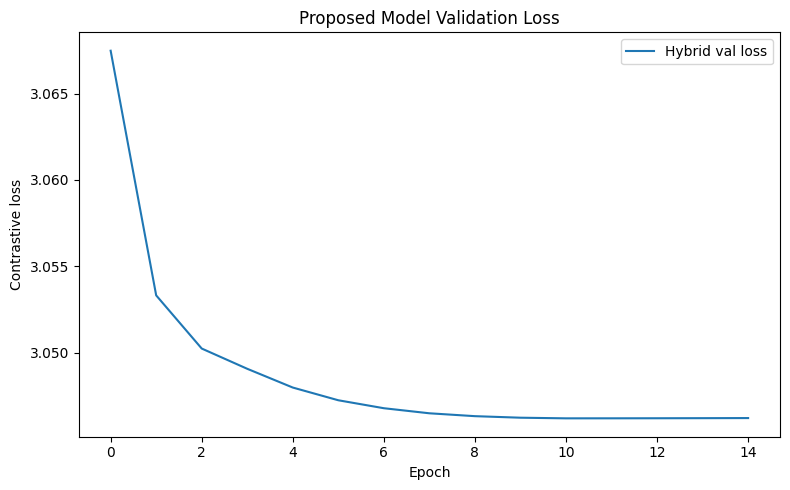

In [19]:
plt.figure(figsize=(8, 5))
plt.plot(hybrid_history['val_loss'], label='Hybrid val loss')
plt.xlabel('Epoch')
plt.ylabel('Contrastive loss')
plt.legend()
plt.title('Proposed Model Validation Loss')
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['figures_dir'], 'fig01_loss_curves.png'), dpi=300)
plt.show()


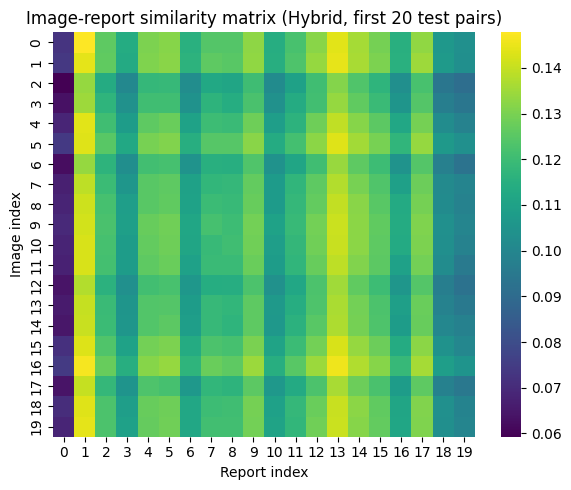

In [20]:
# fig02 - similarity-matrix heatmap (retrieval quality visualization, analogue of confusion matrix here)
hybrid_img_emb, hybrid_text_emb = test_embeddings["hybrid"]
n_show = min(20, len(hybrid_img_emb))
sims = hybrid_img_emb[:n_show] @ hybrid_text_emb[:n_show].T
plt.figure(figsize=(6, 5))
sns.heatmap(sims, cmap="viridis")
plt.xlabel("Report index"); plt.ylabel("Image index")
plt.title("Image-report similarity matrix (Hybrid, first 20 test pairs)")
plt.tight_layout(); plt.savefig(os.path.join(CONFIG["figures_dir"], "fig02_confusion_or_scatter.png"), dpi=300); plt.show()


### Explainable AI

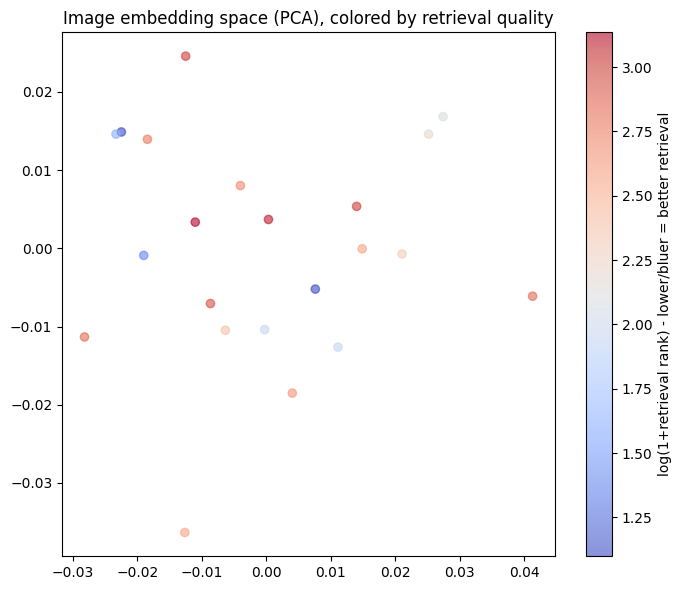

In [21]:
# fig04 - embedding-space PCA colored by nearest-neighbor rank quality (which pairs retrieve well)
from sklearn.decomposition import PCA
pca = PCA(n_components=2).fit(hybrid_img_emb)
img_2d = pca.transform(hybrid_img_emb)
sims_full = hybrid_img_emb @ hybrid_text_emb.T
ranks_full = np.array([np.where(np.argsort(-sims_full[i]) == i)[0][0] + 1 for i in range(len(sims_full))])

plt.figure(figsize=(7, 6))
sc = plt.scatter(img_2d[:, 0], img_2d[:, 1], c=np.log1p(ranks_full), cmap="coolwarm", alpha=0.6)
plt.colorbar(sc, label="log(1+retrieval rank) - lower/bluer = better retrieval")
plt.title("Image embedding space (PCA), colored by retrieval quality")
plt.tight_layout(); plt.savefig(os.path.join(CONFIG["figures_dir"], "fig04_feature_importance.png"), dpi=300); plt.show()


### Error Analysis

10 worst-retrieved test pairs (highest rank = worst):
    rank
0     22
19    21
18    19
20    19
21    18
3     16
10    16
6     15
16    14
11    13


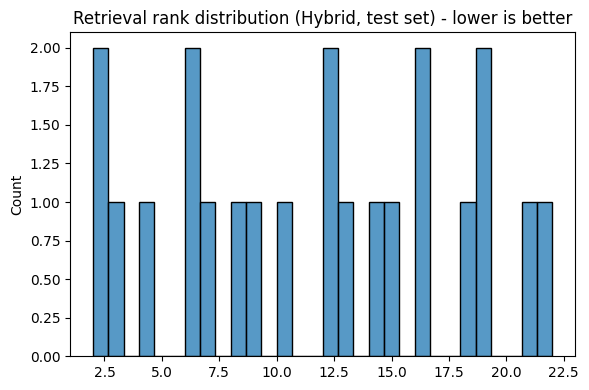

In [22]:
worst_idx = np.argsort(-ranks_full)[:10]
print("10 worst-retrieved test pairs (highest rank = worst):")
print(pd.DataFrame({"rank": ranks_full[worst_idx]}, index=worst_idx))

plt.figure(figsize=(6, 4))
sns.histplot(ranks_full, bins=30)
plt.title("Retrieval rank distribution (Hybrid, test set) - lower is better")
plt.tight_layout(); plt.savefig(os.path.join(CONFIG["figures_dir"], "fig05_error_analysis.png"), dpi=300); plt.show()


### Computational Efficiency

In [23]:
import time
efficiency = {}
for name, model in [('hybrid', hybrid)]:
    total_params = sum((p.numel() for p in model.parameters()))
    trainable_params = sum((p.numel() for p in model.parameters() if p.requires_grad))
    model.eval()
    xi_b, xt_b = next(iter(test_loader))
    xi_b, xt_b = (xi_b.to(DEVICE), xt_b.to(DEVICE))
    with torch.no_grad():
        for _ in range(3):
            model(xi_b, xt_b) if not isinstance(model, HybridModel) else model(xi_b, xt_b, add_noise=False)
        start = time.time()
        for _ in range(20):
            model(xi_b, xt_b) if not isinstance(model, HybridModel) else model(xi_b, xt_b, add_noise=False)
        elapsed = (time.time() - start) / 20
    efficiency[name] = {'total_params': total_params, 'trainable_params': trainable_params, 'avg_batch_inference_time_sec': elapsed, 'throughput_samples_per_sec': xi_b.shape[0] / elapsed}
print(json.dumps(efficiency, indent=2))
with open(os.path.join(CONFIG['results_dir'], 'efficiency.json'), 'w') as f:
    json.dump(efficiency, f, indent=2)


{
  "hybrid": {
    "total_params": 656640,
    "trainable_params": 656640,
    "avg_batch_inference_time_sec": 0.0038088202476501466,
    "throughput_samples_per_sec": 5776.066752841096
  }
}
